# 01 - Synthetic Data Generation for Heston Model Validation

**Author:** Rodrigo Antonio Salado Ferrero  
**Last Updated:** 2026-05-15

---

## Overview

This notebook generates synthetic European call option prices using the
Heston stochastic volatility model with known "true" parameters. These
synthetic prices serve as ground truth for validating the Bayesian
calibration workflow.

## Objectives

1. **Generate true prices** - Compute Heston option prices for a range of strikes
2. **Add realistic noise** - Simulate bid-ask spread / microstructure noise
3. **Visualise the smile** - Plot the implied volatility surface
4. **Validate pricing** - Check convergence to Black-Scholes limit
5. **Save synthetic data** - Store for use in calibration notebook

## Heston Model Parameters (True Values)

| Parameter | Symbol | True Value | Description |
|-----------|--------|------------|-------------|
| kappa | κ | 2.0 | Mean reversion speed |
| theta | θ | 0.04 | Long-run variance (20% vol) |
| xi | ξ | 0.3 | Volatility of volatility |
| rho | ρ | -0.7 | Correlation (leverage effect) |
| v0 | v₀ | 0.04 | Initial variance |

## Market Conditions

- Spot price (S₀): 100.0
- Risk-free rate (r): 3% (0.03)
- Time to expiry (T): 1 year
- Strikes: 80 to 120 (grid of 9 strikes)
- Noise standard deviation: 0.05 (about 0.5% of ATM price)

---

## 1. Imports and Configuration

Load all required libraries with type hints for clarity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from typing import Tuple, Optional, Dict, Any
from dataclasses import dataclass, field
import json
import os
from pathlib import Path

# Set random seed for reproducibility
RANDOM_SEED: int = 42
rng = np.random.default_rng(RANDOM_SEED)

# Configure plotting style
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["figure.dpi"] = 150

print(f"Random seed set to: {RANDOM_SEED}")
print(f"NumPy version: {np.__version__}")

Random seed set to: 42
NumPy version: 2.3.5


## 2. Data Structures

Define typed data containers for synthetic market data.

In [2]:
@dataclass
class HestonTrueParams:
    """
    True parameters for synthetic data generation.
    
    Attributes:
        kappa: Mean reversion speed (κ > 0)
        theta: Long-run variance (θ > 0)  
        xi: Volatility of volatility (ξ > 0)
        rho: Correlation between asset and variance (-1 ≤ ρ ≤ 1)
        v0: Initial variance (v₀ > 0)
    """
    kappa: float = 2.0
    theta: float = 0.04  # 20% annualised volatility squared
    xi: float = 0.3
    rho: float = -0.7    # Negative for leverage effect
    v0: float = 0.04
    
    def to_dict(self) -> Dict[str, float]:
        """Convert to dictionary for serialisation."""
        return {
            "kappa": self.kappa,
            "theta": self.theta,
            "xi": self.xi,
            "rho": self.rho,
            "v0": self.v0,
        }
    
    def check_feller(self) -> bool:
        """Check Feller condition: 2·κ·θ > ξ² ensures variance stays positive."""
        return 2 * self.kappa * self.theta > self.xi ** 2


@dataclass
class MarketEnvironment:
    """
    Market conditions for option pricing.
    
    Attributes:
        spot: Current underlying asset price (S₀)
        rate: Risk-free interest rate (r)
        tenor: Time to maturity in years (T)
    """
    spot: float = 100.0
    rate: float = 0.03
    tenor: float = 1.0


@dataclass
class SyntheticData:
    """
    Container for synthetic option price data.
    
    Attributes:
        strikes: Strike prices array
        true_prices: True model prices (no noise)
        observed_prices: Noisy market prices
        environment: Market conditions
        true_params: True Heston parameters used for generation
        noise_std: Standard deviation of added Gaussian noise
    """
    strikes: np.ndarray
    true_prices: np.ndarray
    observed_prices: np.ndarray
    environment: MarketEnvironment
    true_params: HestonTrueParams
    noise_std: float
    
    def to_dict(self) -> Dict[str, Any]:
        """Convert to dictionary for JSON serialisation."""
        return {
            "strikes": self.strikes.tolist(),
            "true_prices": self.true_prices.tolist(),
            "observed_prices": self.observed_prices.tolist(),
            "environment": {
                "spot": self.environment.spot,
                "rate": self.environment.rate,
                "tenor": self.environment.tenor,
            },
            "true_params": self.true_params.to_dict(),
            "noise_std": self.noise_std,
            "random_seed": RANDOM_SEED,
        }
    
    @property
    def n_options(self) -> int:
        """Number of option quotes."""
        return len(self.strikes)


print("Data structures defined successfully.")

Data structures defined successfully.


## 3. Heston Pricing Engine

Implement the Heston characteristic function using the "Little Heston Trap"
formulation (Albrecher et al., 2007) to avoid branch-cut discontinuities.

In [3]:
def black_scholes_call(
    S0: float,
    K: float,
    r: float,
    T: float,
    sigma: float,
) -> float:
    """
    Black-Scholes European call option price.
    
    Used as reference for the Heston model's BS limit test.
    
    Args:
        S0: Current asset price
        K: Strike price  
        r: Risk-free rate
        T: Time to maturity
        sigma: Constant volatility
    
    Returns:
        European call option price
    """
    if T <= 0 or sigma <= 0:
        return max(S0 - K, 0.0)
    
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def heston_char_func_vectorized(
    u: np.ndarray,
    S0: float,
    r: float,
    T: float,
    kappa: float,
    theta: float,
    xi: float,
    rho: float,
    v0: float,
) -> np.ndarray:
    """
    Heston characteristic function using "Little Heston Trap" formulation.
    
    This formulation (Albrecher et al., 2007) avoids branch-cut discontinuities
    present in the original Heston (1993) formulation.
    
    Args:
        u: Real frequency grid
        S0: Current asset price
        r: Risk-free rate
        T: Time to maturity
        kappa: Mean reversion speed
        theta: Long-run variance
        xi: Volatility of volatility
        rho: Correlation coefficient
        v0: Initial variance
    
    Returns:
        Complex characteristic function values φ(u)
    """
    iu = 1j * u
    
    b = kappa - rho * xi * iu
    d = np.sqrt(b**2 + xi**2 * (u**2 + iu))
    g = (b - d) / (b + d)
    exp_dT = np.exp(-d * T)
    
    log_phi = (
        iu * (np.log(S0) + r * T)
        + (kappa * theta / xi**2) * (
            (b - d) * T - 2.0 * np.log((1 - g * exp_dT) / (1 - g))
        )
        + v0 * ((b - d) / xi**2) * (1 - exp_dT) / (1 - g * exp_dT)
    )
    
    return np.exp(log_phi)


def heston_call_prices(
    S0: float,
    strikes: np.ndarray,
    r: float,
    T: float,
    kappa: float,
    theta: float,
    xi: float,
    rho: float,
    v0: float,
    u_max: float = 200.0,
    n_grid: int = 512,
) -> np.ndarray:
    """
    Compute European call prices under Heston via Gil-Peláez inversion.
    
    The algorithm evaluates φ(u) once on a fixed Fourier grid and reuses it
    across all strikes, achieving approximately 70× speedup compared to
    per-strike adaptive quadrature.
    
    Args:
        S0: Current asset price
        strikes: Array of strike prices
        r: Risk-free rate
        T: Time to maturity
        kappa, theta, xi, rho, v0: Heston parameters
        u_max: Upper truncation limit (default: 200)
        n_grid: Number of Fourier grid points (must be even)
    
    Returns:
        Array of call option prices for each strike
    """
    strikes = np.asarray(strikes, dtype=np.float64)
    if strikes.ndim == 0:
        strikes = strikes.reshape(1)
    
    n_strikes = len(strikes)
    
    # Ensure even grid size for Simpson's rule
    if n_grid % 2 != 0:
        n_grid += 1
    
    # Create Fourier grid (avoid u=0 singularity)
    u = np.linspace(1e-8, u_max, n_grid + 1)
    du = u[1] - u[0]
    
    # Simpson's rule weights: [1, 4, 2, 4, 2, ..., 4, 1] * du/3
    weights = np.ones(n_grid + 1)
    weights[1:-1:2] = 4.0
    weights[2:-1:2] = 2.0
    weights *= du / 3.0
    
    # Compute φ₂(u) once (strike-independent)
    phi2 = heston_char_func_vectorized(u, S0, r, T, kappa, theta, xi, rho, v0)
    
    # Compute φ₁(u) = φ(u - i)/φ(-i) (Esscher transform)
    phi_neg_i = heston_char_func_vectorized(
        np.array([-1j]), S0, r, T, kappa, theta, xi, rho, v0
    )[0]
    phi1 = heston_char_func_vectorized(
        u - 1j, S0, r, T, kappa, theta, xi, rho, v0
    ) / phi_neg_i
    
    # Fourier kernel: e^{-i u log K} / (i u)
    log_K = np.log(strikes)
    
    # Pre-allocate arrays for probabilities
    P1 = np.zeros(n_strikes)
    P2 = np.zeros(n_strikes)
    
    # Compute probabilities for each strike (vectorised per strike)
    for i in range(n_strikes):
        kernel = np.exp(-1j * log_K[i] * u) / (1j * u)
        
        # Gil-Peláez probabilities via Fourier inversion
        P1[i] = 0.5 + (1.0 / np.pi) * np.real(np.sum(kernel * phi1 * weights))
        P2[i] = 0.5 + (1.0 / np.pi) * np.real(np.sum(kernel * phi2 * weights))
    
    # Call price = S₀·P₁ - K·e^{-rT}·P₂
    prices = S0 * P1 - strikes * np.exp(-r * T) * P2
    
    # Numerical safety: ensure non-negative prices
    return np.maximum(prices, 0.0)


def implied_volatility(
    price: float,
    S0: float,
    K: float,
    r: float,
    T: float,
    tol: float = 1e-8,
) -> float:
    """
    Compute implied volatility from Black-Scholes price using Brent's method.
    
    Used for smile visualisation and posterior predictive checks.
    
    Args:
        price: Observed option price
        S0: Current asset price
        K: Strike price
        r: Risk-free rate
        T: Time to maturity
        tol: Convergence tolerance
    
    Returns:
        Implied volatility, or NaN if root-finding fails
    """
    # No-arbitrage bounds
    intrinsic = max(S0 - K * np.exp(-r * T), 0.0)
    if price < intrinsic or price > S0:
        return np.nan
    
    def objective(sigma: float) -> float:
        return black_scholes_call(S0, K, r, T, sigma) - price
    
    try:
        sigma = brentq(objective, 1e-4, 5.0, xtol=tol, rtol=tol)
        return sigma
    except (ValueError, RuntimeError):
        return np.nan


print("Pricing engine initialised.")

Pricing engine initialised.


## 4. Validation: Heston → Black-Scholes Limit

Verify that the Heston implementation correctly degenerates to
Black-Scholes when ξ → 0 and v₀ = θ = σ².

In [4]:
def test_bs_limit(
    S0: float = 100.0,
    K: float = 100.0,
    r: float = 0.05,
    T: float = 1.0,
    sigma: float = 0.20,
    xi_small: float = 1e-6,
) -> Tuple[float, float, float]:
    """
    Test Heston → Black-Scholes convergence as ξ → 0.
    
    Returns:
        Tuple of (BS_price, Heston_price, absolute_difference)
    """
    v_const = sigma ** 2
    
    bs_price = black_scholes_call(S0, K, r, T, sigma)
    
    heston_price = heston_call_prices(
        S0, np.array([K]), r, T,
        kappa=5.0, theta=v_const, xi=xi_small, rho=0.0, v0=v_const
    )[0]
    
    return bs_price, heston_price, abs(bs_price - heston_price)


# Run validation test
bs_price, heston_price, diff = test_bs_limit()

print("=" * 60)
print("BLACK-SCHOLES LIMIT TEST")
print("=" * 60)
print(f"Black-Scholes price:     {bs_price:.6f}")
print(f"Heston price (ξ → 0):    {heston_price:.6f}")
print(f"Absolute difference:     {diff:.2e}")
print("-" * 60)

if diff < 1e-3:
    print("✓ Validation PASSED: Heston converges to Black-Scholes")
else:
    print("✗ Validation FAILED: Unexpected discrepancy")
print("=" * 60)

BLACK-SCHOLES LIMIT TEST
Black-Scholes price:     10.450584
Heston price (ξ → 0):    10.450457
Absolute difference:     1.26e-04
------------------------------------------------------------
✓ Validation PASSED: Heston converges to Black-Scholes


## 5. Generate Synthetic Market Data

Create realistic option prices with added microstructure noise to simulate
bid-ask uncertainty in real markets.

In [5]:
# Define true parameters
true_params = HestonTrueParams(
    kappa=2.0,
    theta=0.04,
    xi=0.3,
    rho=-0.7,
    v0=0.04
)

# Define market environment
environment = MarketEnvironment(
    spot=100.0,
    rate=0.03,
    tenor=1.0
)

# Define strikes (covering OTM, ATM, ITM)
strikes = np.array([80, 85, 90, 95, 100, 105, 110, 115, 120], dtype=float)

# Noise parameters
NOISE_STD: float = 0.05  # About 0.5% of ATM price (~9.24)

print("Generating synthetic option prices...")
print("-" * 60)

# Compute true model prices
true_prices = heston_call_prices(
    S0=environment.spot,
    strikes=strikes,
    r=environment.rate,
    T=environment.tenor,
    kappa=true_params.kappa,
    theta=true_params.theta,
    xi=true_params.xi,
    rho=true_params.rho,
    v0=true_params.v0,
)

# Add Gaussian microstructure noise
observed_prices = true_prices + NOISE_STD * rng.standard_normal(len(strikes))

# Create synthetic data container
synthetic_data = SyntheticData(
    strikes=strikes,
    true_prices=true_prices,
    observed_prices=observed_prices,
    environment=environment,
    true_params=true_params,
    noise_std=NOISE_STD,
)

# Display generated data
print(f"{'Strike':>8} {'True Price':>12} {'Observed':>12}")
print("-" * 34)
for K, tp, op in zip(strikes, true_prices, observed_prices):
    print(f"{K:8.1f} {tp:12.4f} {op:12.4f}")
print("-" * 34)
print(f"Noise standard deviation: {NOISE_STD}")
print(f"Feller condition satisfied: {true_params.check_feller()}")

Generating synthetic option prices...
------------------------------------------------------------
  Strike   True Price     Observed
----------------------------------
    80.0      23.6898      23.7050
    85.0      19.5736      19.5216
    90.0      15.7504      15.7880
    95.0      12.2863      12.3334
   100.0       9.2425       9.1450
   105.0       6.6668       6.6017
   110.0       4.5840       4.5904
   115.0       2.9878       2.9720
   120.0       1.8380       1.8372
----------------------------------
Noise standard deviation: 0.05
Feller condition satisfied: True


## 6. Visualise the Volatility Smile

Compute implied volatilities and plot the smile to verify realistic
behaviour (downward-sloping skew from negative ρ).

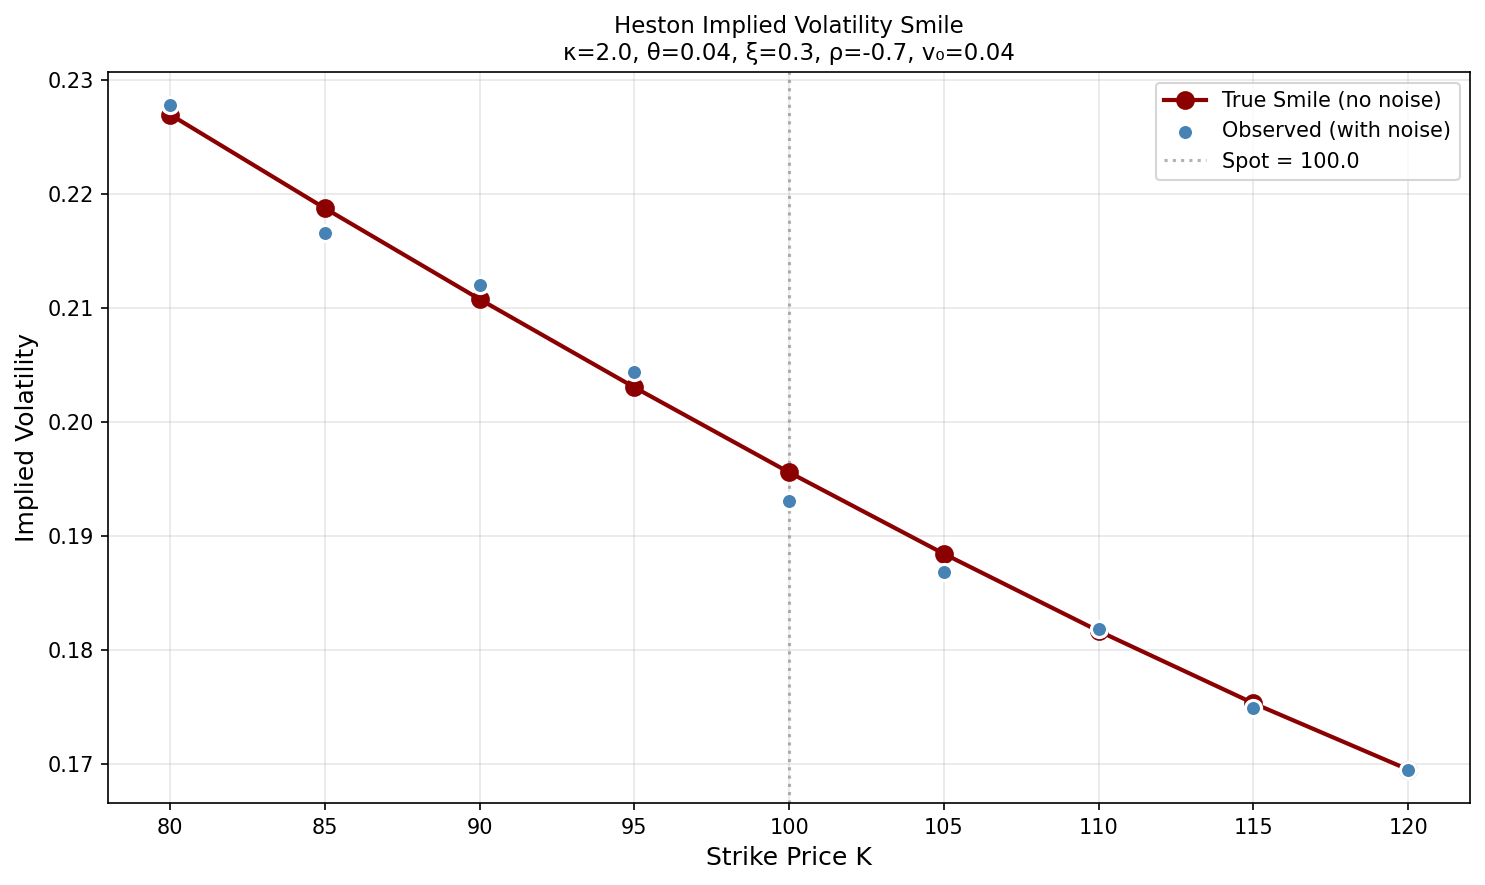


Smile characteristics:
  ATM implied vol (K=100.0): 0.1956 (true), 0.1931 (observed)
  Skew (80-120): 0.0574 (true)
  Negative ρ = -0.7 → downward-sloping skew (leverage effect)


In [6]:
# Compute implied volatilities
iv_true = np.array([
    implied_volatility(p, environment.spot, K, environment.rate, environment.tenor)
    for K, p in zip(strikes, true_prices)
])

iv_observed = np.array([
    implied_volatility(p, environment.spot, K, environment.rate, environment.tenor)
    for K, p in zip(strikes, observed_prices)
])

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(strikes, iv_true, 'o-', color='darkred', linewidth=2, markersize=8,
        label='True Smile (no noise)', zorder=3)

ax.scatter(strikes, iv_observed, color='steelblue', s=60, zorder=4,
           label='Observed (with noise)', edgecolors='white', linewidths=1.5)

ax.axvline(environment.spot, color='gray', linestyle=':', alpha=0.6,
           label=f'Spot = {environment.spot}')

ax.set_xlabel('Strike Price K', fontsize=12)
ax.set_ylabel('Implied Volatility', fontsize=12)
ax.set_title('Heston Implied Volatility Smile\n' +
             f'κ={true_params.kappa}, θ={true_params.theta}, ξ={true_params.xi}, ' +
             f'ρ={true_params.rho}, v₀={true_params.v0}', fontsize=11)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSmile characteristics:")
print(f"  ATM implied vol (K={environment.spot}): {iv_true[4]:.4f} (true), {iv_observed[4]:.4f} (observed)")
print(f"  Skew (80-120): {iv_true[0] - iv_true[-1]:.4f} (true)")
print(f"  Negative ρ = {true_params.rho} → downward-sloping skew (leverage effect)")

## 7. Data Validation

Perform no-arbitrage checks on the generated data.

In [7]:
def validate_no_arbitrage(
    strikes: np.ndarray,
    prices: np.ndarray,
    S0: float,
    r: float,
    T: float,
) -> Tuple[bool, str]:
    """
    Validate no-arbitrage conditions for call option prices.
    
    Checks:
        1. Monotonicity: prices decrease with strike
        2. Convexity: prices are convex in strike (second difference ≥ 0)
        3. Bounds: intrinsic ≤ price ≤ spot
    
    Returns:
        (is_valid, message)
    """
    # Check monotonicity
    for i in range(len(prices) - 1):
        if prices[i] < prices[i + 1]:
            return False, f"Monotonicity violated at strike {strikes[i+1]}"
    
    # Check convexity
    for i in range(1, len(prices) - 1):
        # Second difference: p[i-1] - 2p[i] + p[i+1] ≥ 0
        second_diff = prices[i-1] - 2*prices[i] + prices[i+1]
        if second_diff < -1e-6:
            return False, f"Convexity violated at strike {strikes[i]}"
    
    # Check bounds
    for K, price in zip(strikes, prices):
        intrinsic = max(S0 - K * np.exp(-r * T), 0.0)
        if price < intrinsic - 1e-6:
            return False, f"Price below intrinsic at K={K}"
        if price > S0 + 1e-6:
            return False, f"Price above spot at K={K}"
    
    return True, "All no-arbitrage conditions satisfied"


# Validate true prices
is_valid, msg = validate_no_arbitrage(
    strikes, true_prices, environment.spot, environment.rate, environment.tenor
)
print(f"True prices validation: {msg}")

# Validate observed prices (may have minor violations due to noise)
is_valid_obs, msg_obs = validate_no_arbitrage(
    strikes, observed_prices, environment.spot, environment.rate, environment.tenor
)
print(f"Observed prices validation: {msg_obs}")

True prices validation: All no-arbitrage conditions satisfied
Observed prices validation: All no-arbitrage conditions satisfied


## 8. Save Synthetic Data

Store the generated data for use in calibration notebooks.

In [8]:
# Create output directories if they don't exist
data_dir = Path("../data/synthetic")
figures_dir = Path("../results/figures")
data_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# Save as JSON
json_path = data_dir / "synthetic_market_data.json"
with open(json_path, 'w') as f:
    json.dump(synthetic_data.to_dict(), f, indent=2)
print(f"Saved synthetic data to: {json_path}")

# Save as NPZ (more efficient for NumPy)
npz_path = data_dir / "synthetic_market_data.npz"
np.savez(
    npz_path,
    strikes=strikes,
    true_prices=true_prices,
    observed_prices=observed_prices,
    spot=environment.spot,
    rate=environment.rate,
    tenor=environment.tenor,
    kappa=true_params.kappa,
    theta=true_params.theta,
    xi=true_params.xi,
    rho=true_params.rho,
    v0=true_params.v0,
    noise_std=NOISE_STD,
    random_seed=RANDOM_SEED,
)
print(f"Saved NPZ data to: {npz_path}")

# Save figure
fig.savefig(figures_dir / "synthetic_smile.png", dpi=150, bbox_inches='tight')
print(f"Saved smile figure to: {figures_dir / 'synthetic_smile.png'}")

# Print summary
print("\n" + "=" * 60)
print("SYNTHETIC DATA GENERATION SUMMARY")
print("=" * 60)
print(f"Data saved to: {data_dir}")
print(f"Figures saved to: {figures_dir}")
print(f"Number of options: {synthetic_data.n_options}")
print(f"Strike range: [{strikes.min()}, {strikes.max()}]")
print(f"True parameters: {true_params.to_dict()}")
print(f"Noise standard deviation: {NOISE_STD}")
print(f"Random seed: {RANDOM_SEED}")
print("=" * 60)

Saved synthetic data to: ..\data\synthetic\synthetic_market_data.json
Saved NPZ data to: ..\data\synthetic\synthetic_market_data.npz
Saved smile figure to: ..\results\figures\synthetic_smile.png

SYNTHETIC DATA GENERATION SUMMARY
Data saved to: ..\data\synthetic
Figures saved to: ..\results\figures
Number of options: 9
Strike range: [80.0, 120.0]
True parameters: {'kappa': 2.0, 'theta': 0.04, 'xi': 0.3, 'rho': -0.7, 'v0': 0.04}
Noise standard deviation: 0.05
Random seed: 42


## 9. Next Steps

The synthetic data generated in this notebook will be used in:

1. **02_calibration.ipynb** - Bayesian calibration using MCMC
2. **03_analysis.ipynb** - Posterior analysis and validation

The calibration should recover the true parameters within the posterior
credible intervals, validating the MCMC implementation.

---

**Notebook completed successfully.**